# EDA

In [ ]:
import pandas as pd
import numpy as np

df2 = pd.read_csv('итогAPI (2).csv')

делаем рейтинг числом

In [ ]:
df_clean = df2.copy()

# Заменяем 'нет рейтинга' на NaN и преобразуем в числовой формат
df_clean['рейтинг'] = pd.to_numeric(df_clean['рейтинг'].replace('нет рейтинга', np.nan), errors='coerce')

# Удаляем строки с отсутствующими рейтингами для некоторых графиков
df_with_rating = df_clean.dropna(subset=['рейтинг'])

print(f"Всего записей: {len(df2)}")
print(f"Записей с рейтингом: {len(df_with_rating)}")
print(f"Пропущенных рейтингов: {len(df_clean) - len(df_with_rating)}")

Всего записей: 21218
Записей с рейтингом: 15962
Пропущенных рейтингов: 5256


In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:

rating_by_type = df_with_rating.groupby('тип')['рейтинг'].median().sort_values(ascending=False)
df_sorted = df_with_rating.copy()
df_sorted['тип'] = pd.Categorical(df_sorted['тип'], categories=rating_by_type.index, ordered=True)

fig = px.box(
    df_sorted,
    x="тип",
    y="рейтинг",
    color="тип",
    title="Распределение рейтингов по типам объектов"
)
fig.update_layout(
    title_font_size=16,
    title_x = 0.5,
    xaxis_title="Тип объекта",
    yaxis_title="Рейтинг",
    showlegend=False
)
fig.show()

In [ ]:
df2 = df_sorted.copy()

In [ ]:
fig = px.pie(
    names=df2['тип'].value_counts().index,
    values=df2['тип'].value_counts().values,
    title='Распределение типов объектов',
    template='plotly_white'
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(
    title_font_size=20,
    title_x=0.5,
    showlegend=False
)
fig.show()

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('okey (3).csv', index_col=0)

In [ ]:
# Колонки с количеством объектов
density_columns = [
    'number_of_business_centers_per_km2',
    'number_of_kindergartens_per_km2',
    'number_of_cafes_per_km2',
    'number_of_stores_per_km2',
    'number_of_museums_per_km2',
    'number_of_clinics_per_km2',
    'number_of_shopping_centers_per_km2',
    'number_of_schools_per_km2'
]

# Веса для каждого типа объектов
weights = [0.09, 0.16, 0.12, 0.18, 0.06, 0.14, 0.10, 0.15]

# Колонки с рейтингами объектов
rating_columns = [
    'average_rating_business_center_in_area',
    'average_rating_kindergarten_in_area',
    'average_rating_cafe_in_area',
    'average_rating_store_in_area',
    'average_rating_museum_in_area',
    'average_rating_clinic_in_area',
    'average_rating_shopping_center_in_area',
    'average_rating_school_in_area'
]

# Умножаем количество на вес и на рейтинг
weighted_scores = []
for i in range(len(density_columns)):
    quantity = df[density_columns[i]]
    rating = df[rating_columns[i]]
    weight = weights[i]
    weighted_score = quantity * weight * rating
    weighted_scores.append(weighted_score)

# 2. Суммируем все взвешенные оценки
weighted_df = pd.concat(weighted_scores, axis=1)
infrastructure_raw_score = weighted_df.sum(axis=1)

# 3. Рассчитываем СРЕДНЕЕ расстояние до метро по каждому району
avg_metro_by_area = df.groupby('area')['distance_to_nearest_metro'].mean()

# 4. Добавляем среднее расстояние до метро к основным данным
df['avg_distance_to_metro_in_area'] = df['area'].map(avg_metro_by_area)

# 5. Добавляем фактор метро (чем ближе - тем лучше)
# Нормализуем chtlytt расстояние до метро по району
metro_min = df['avg_distance_to_metro_in_area'].min()
metro_max = df['avg_distance_to_metro_in_area'].max()
metro_score = 1 - (df['avg_distance_to_metro_in_area'] - metro_min) / (metro_max - metro_min)

# 6. Комбинируем инфраструктуру и доступность метро
# Даем 80% веса инфраструктуре и 20% веса метро
combined_raw_score = infrastructure_raw_score * 0.8 + metro_score * 0.2 * infrastructure_raw_score.max()

# 7. Нормализуем к диапазону 0-100
min_score = combined_raw_score.min()
max_score = combined_raw_score.max()
df['infrastructure_score'] = (combined_raw_score - min_score) / (max_score - min_score) * 100

df['price/quality'] = df['price_per_m2_million_rub'] / df['infrastructure_score']

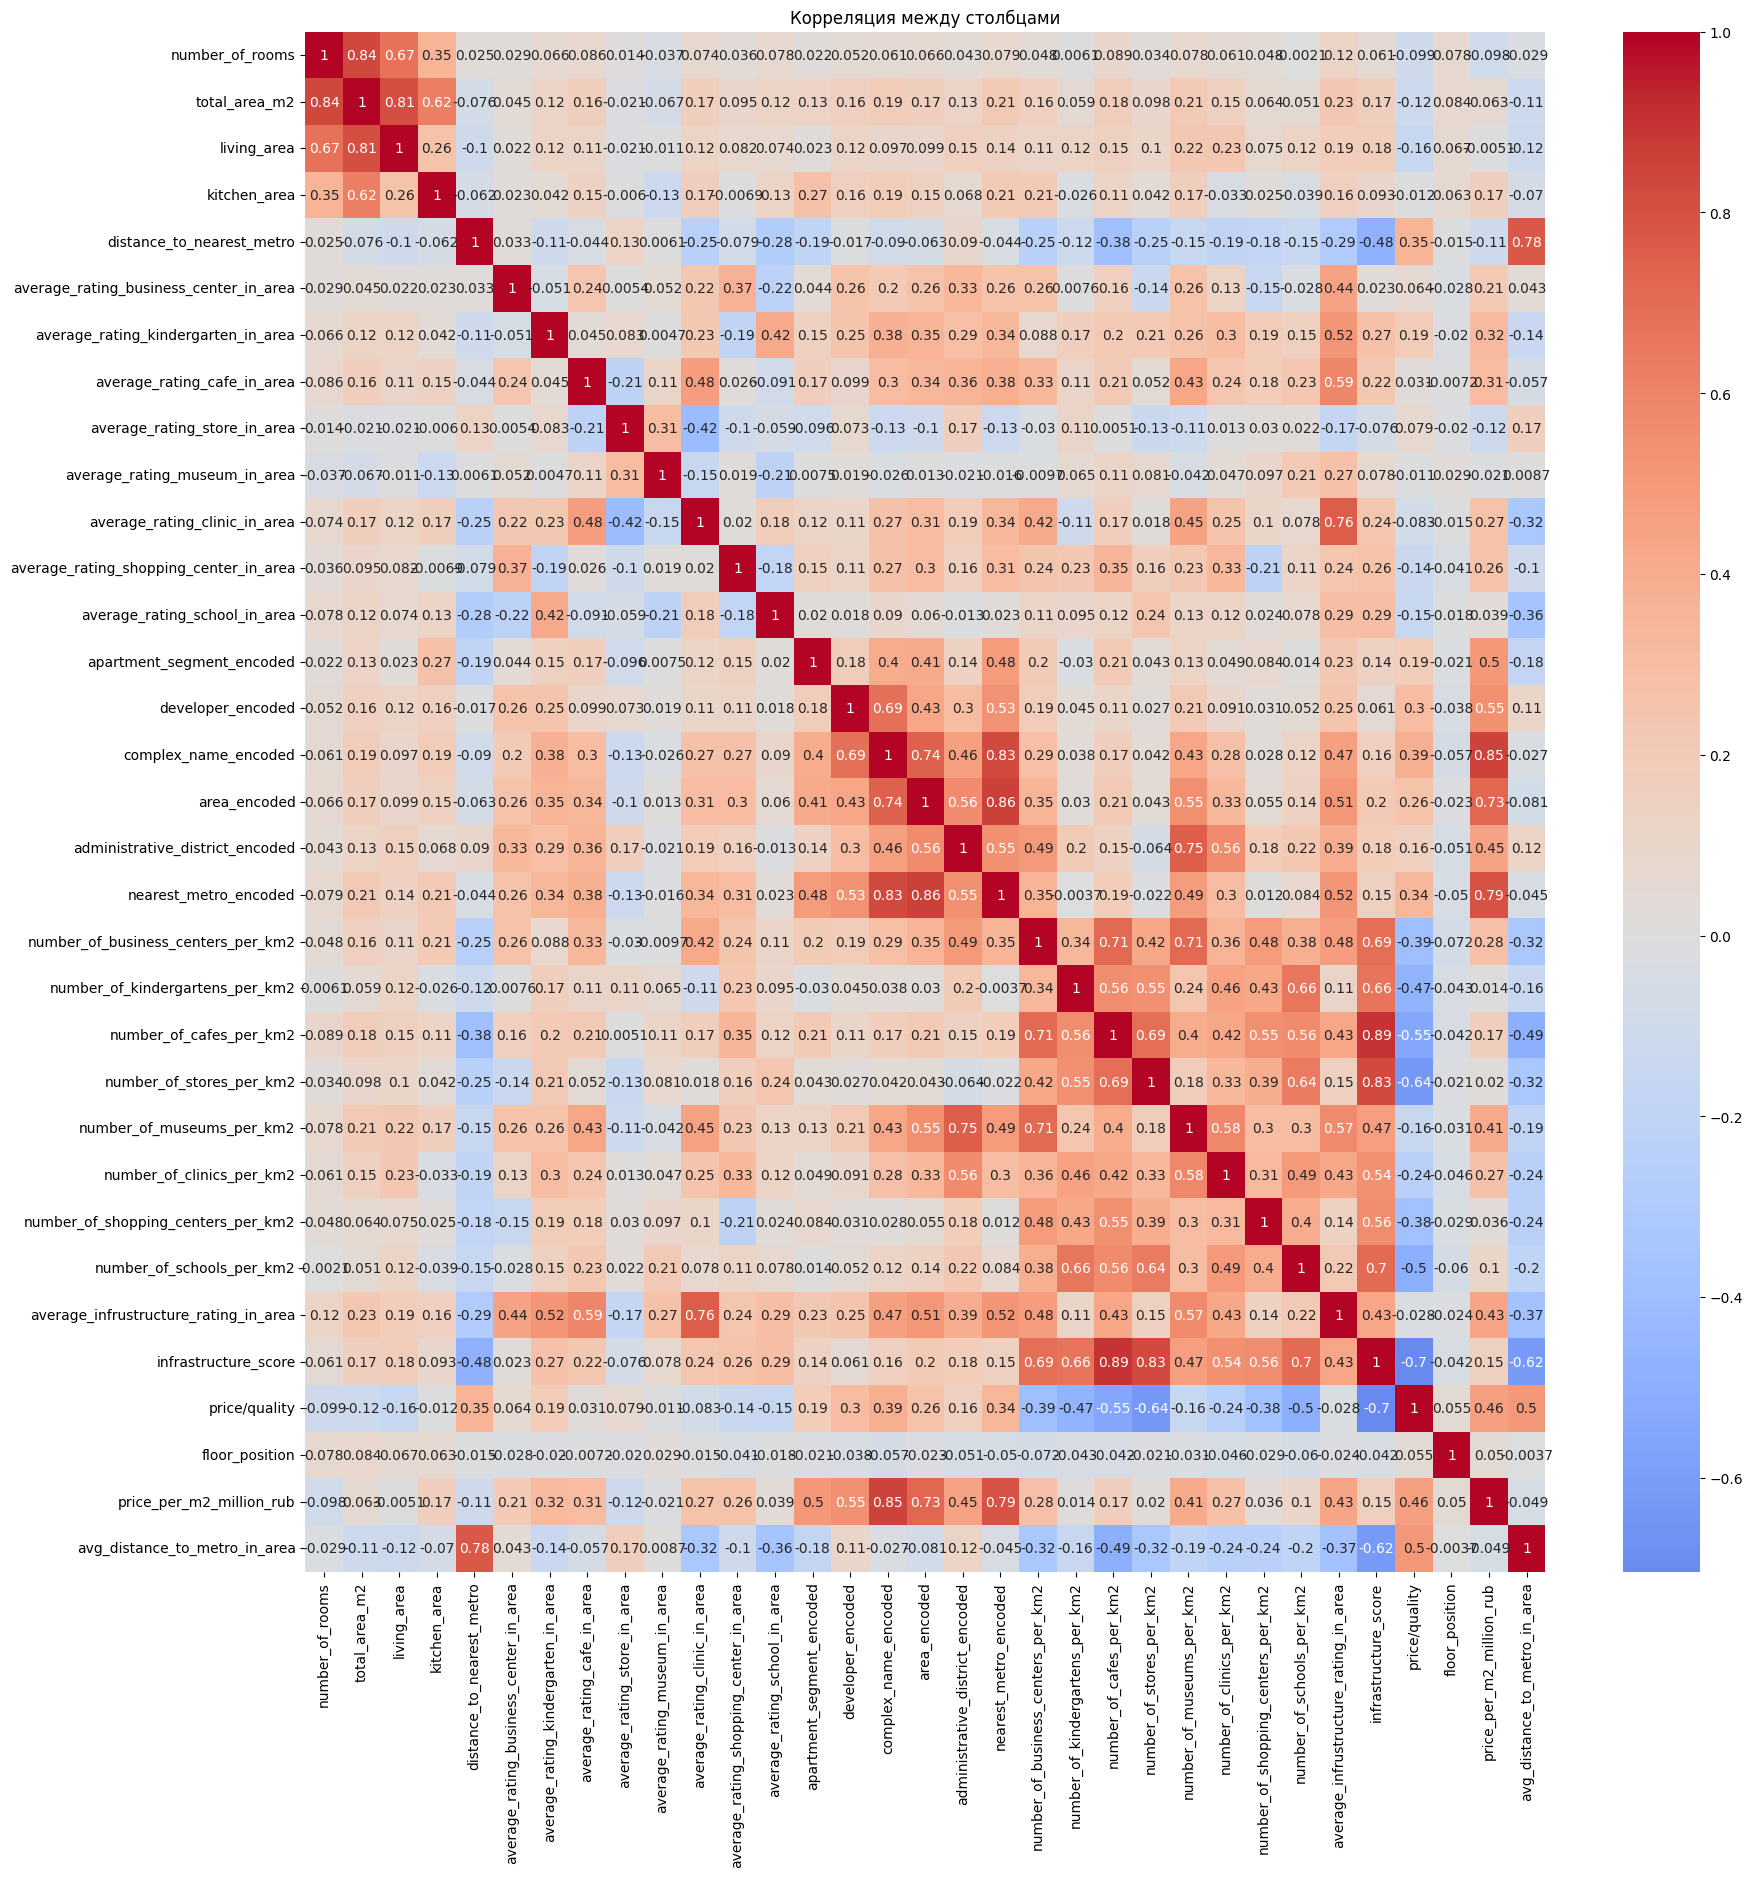

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 20))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)
plt.title('Корреляция между столбцами')
plt.show()

In [ ]:
# Влияние позиции этажа на цену
import plotly.express as px

fig = px.scatter(df, x='floor_position', y='price_per_m2_million_rub',
                 title='Влияние позиции этажа на цену',
                 opacity=0.6,
                 hover_data=['number_of_rooms', 'total_area_m2', 'apartment_segment'])
fig.update_layout(
    xaxis_title='Позиция этажа',
    yaxis_title='Цена за кв.м (млн руб)'
)
fig.show()

In [ ]:
# Цены по категориям этажей
if 'floor_category' not in df.columns:
    df['floor_category'] = pd.cut(df['floor_position'],
                                 bins=[0, 0.25, 0.75, 1],
                                 labels=['нижние', 'средние', 'верхние'])

fig = px.box(df, x='floor_category', y='price_per_m2_million_rub',
              title='Распределение цен по категориям этажей')
fig.update_layout(
    xaxis_title='Категория этажа',
    yaxis_title='Цена за кв.м (млн руб)'
)
fig.show()

In [ ]:
fig = go.Figure()

for rooms in sorted(df['number_of_rooms'].unique()):
    room_data = df[df['number_of_rooms'] == rooms]['price_per_m2_million_rub']
    fig.add_trace(go.Box(
        y=room_data,
        name=f'{rooms} комн.',
        boxpoints='outliers'
    ))

fig.update_layout(
    title='Распределение цен по количеству комнат',
    xaxis_title='Количество комнат',
    yaxis_title='Цена за м² (млн руб)',
    showlegend=False
)


In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['total_area_m2'],
    y=df['price_per_m2_million_rub'],
    mode='markers',
    text=df['apartment_segment'],
    hovertemplate='<b>Площадь:</b> %{x} м²<br><b>Цена за м²:</b> %{y} млн руб<br><b>Сегмент:</b> %{text}<extra></extra>'
))

fig.update_layout(
    title='Зависимость цены от общей площади',
    xaxis_title='Общая площадь (м²)',
    yaxis_title='Цена за м² (млн руб)'
)

fig.show()

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['living_area'],
    y=df['price_per_m2_million_rub'],
    mode='markers',
    text=df['apartment_segment'],
    hovertemplate='<b>Площадь:</b> %{x} м²<br><b>Цена за м²:</b> %{y} млн руб<br><b>Сегмент:</b> %{text}<extra></extra>'
))

fig.update_layout(
    title='Зависимость цены от жилой площади',
    xaxis_title='Жилая площадь (м²)',
    yaxis_title='Цена за м² (млн руб)'
)

fig.show()

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['kitchen_area'],
    y=df['price_per_m2_million_rub'],
    mode='markers',
    text=df['apartment_segment'],
    hovertemplate='<b>Площадь:</b> %{x} м²<br><b>Цена за м²:</b> %{y} млн руб<br><b>Сегмент:</b> %{text}<extra></extra>'
))

fig.update_layout(
    title='Зависимость цены от площади кухни',
    xaxis_title='Площадь кухни (м²)',
    yaxis_title='Цена за м² (млн руб)'
)

fig.show()

In [ ]:
# Сначала получим порядок округов по средней цене (или другому критерию)
district_order = df.groupby('administrative_district')['price_per_m2_million_rub'].mean().sort_values(ascending=False).index.tolist()

# Гистограмма по административным округам
fig = px.histogram(df,
                   x='administrative_district',
                   title='Распределение по административным округам',
                   text_auto=True,
                   category_orders={'administrative_district': district_order})  # задаем порядок
fig.update_layout(
    xaxis_title='Административный округ',
    yaxis_title='Количество квартир'
)
fig.show()

district_price = df.groupby('administrative_district')['price_per_m2_million_rub'].mean().sort_values(ascending=False).reset_index()

fig = px.bar(district_price,
             x='administrative_district',
             y='price_per_m2_million_rub',
             title='Средняя цена за кв.м по округам',
             category_orders={'administrative_district': district_order})  # используем тот же порядок
fig.update_layout(
    xaxis_title='Административный округ',
    yaxis_title='Средняя цена за кв.м (млн руб)'
)
fig.show()

In [ ]:
df3 = pd.read_csv('ok.csv')

In [ ]:
df['distance_to_nearest_metro']

,distance_to_nearest_metro
0,682.0
1,1000.0
2,2000.0
3,2000.0
4,2000.0
...,...
8774,2000.0
8775,2000.0
8776,524.0
8777,2000.0


In [ ]:
import plotly.express as px

fig = px.scatter(df3, x='distance_to_nearest_metro', y='price_per_m2_million_rub',
                 title='Влияние расстояние до метро на цену за кв.м.',
                 opacity=0.6,
                 hover_data=['distance_to_nearest_metro', 'total_area_m2', 'apartment_segment'])
fig.update_layout(
    xaxis_title='Расстояние до метро',
    yaxis_title='Цена за кв.м (млн руб)'
)
fig.show()

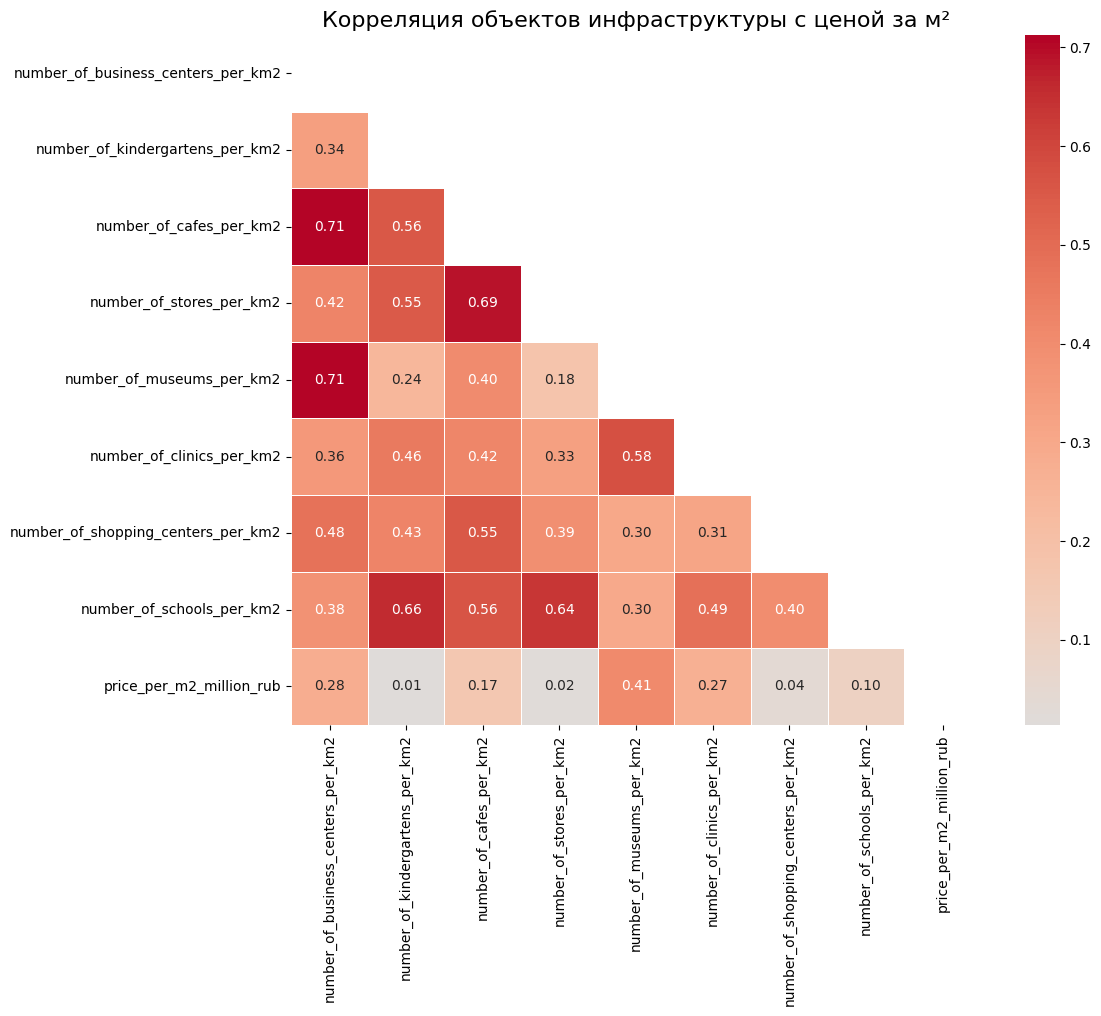

In [ ]:
infrastructure_cols = ['number_of_business_centers_per_km2', 'number_of_kindergartens_per_km2',
                      'number_of_cafes_per_km2', 'number_of_stores_per_km2', 'number_of_museums_per_km2',
                      'number_of_clinics_per_km2', 'number_of_shopping_centers_per_km2',
                      'number_of_schools_per_km2', 'price_per_m2_million_rub']

plt.figure(figsize=(12, 10))
correlation_matrix = df[infrastructure_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Корреляция объектов инфраструктуры с ценой за м²', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['complex_name', 'developer', 'apartment_segment', 'number_of_rooms',
       'total_area_m2', 'living_area', 'kitchen_area', 'nearest_metro',
       'distance_to_nearest_metro', 'link', 'administrative_district', 'area',
       'average_rating_business_center_in_area',
       'average_rating_kindergarten_in_area', 'average_rating_cafe_in_area',
       'average_rating_store_in_area', 'average_rating_museum_in_area',
       'average_rating_clinic_in_area',
       'average_rating_shopping_center_in_area',
       'average_rating_school_in_area', 'apartment_segment_encoded',
       'developer_encoded', 'complex_name_encoded', 'area_encoded',
       'administrative_district_encoded', 'nearest_metro_encoded',
       'number_of_business_centers_per_km2', 'number_of_kindergartens_per_km2',
       'number_of_cafes_per_km2', 'number_of_stores_per_km2',
       'number_of_museums_per_km2', 'number_of_clinics_per_km2',
       'number_of_shopping_centers_per_km2', 'number_of_schools_per_km2',
 

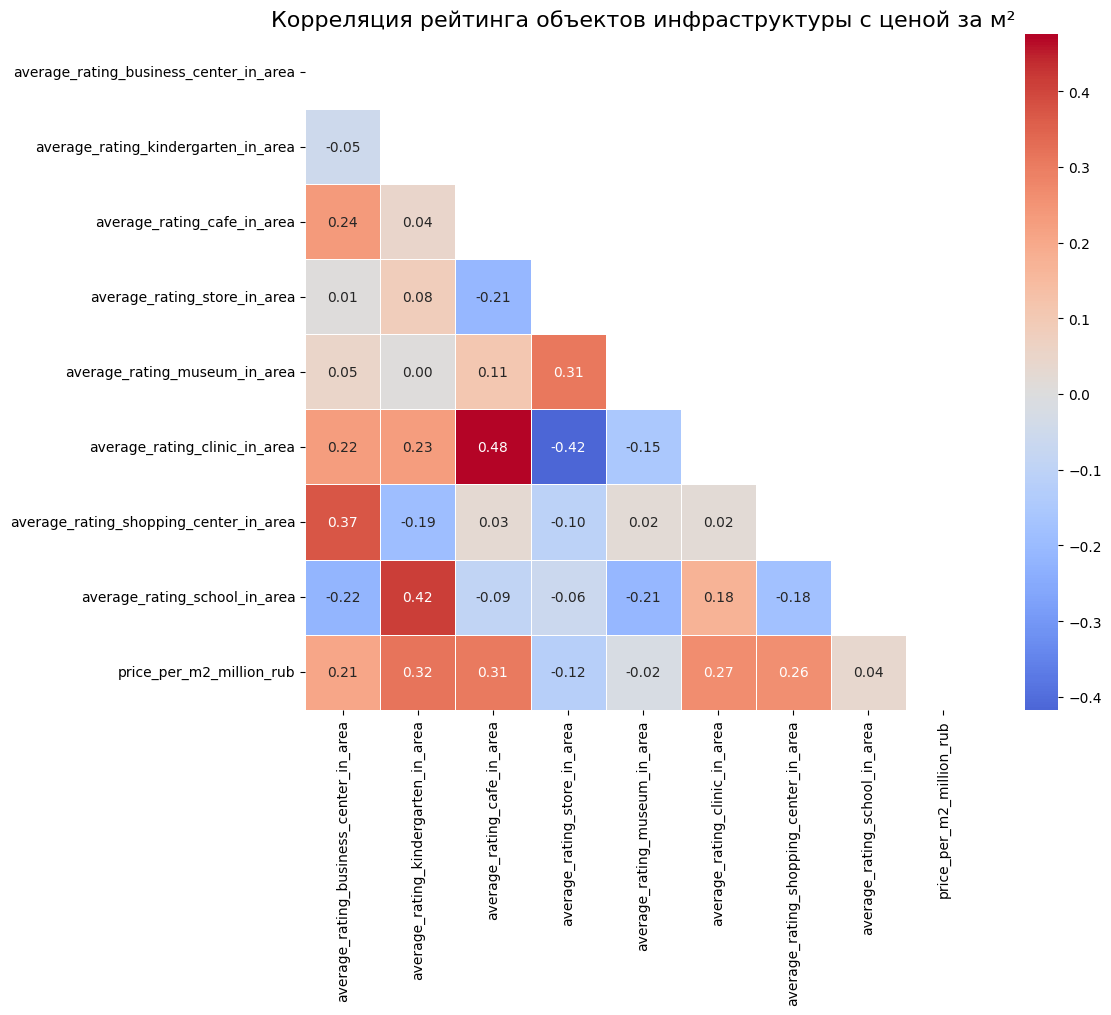

In [ ]:
infrastructure_cols = ['average_rating_business_center_in_area', 'average_rating_kindergarten_in_area', 'average_rating_cafe_in_area',
                       'average_rating_store_in_area', 'average_rating_museum_in_area', 'average_rating_clinic_in_area',
                       'average_rating_shopping_center_in_area', 'average_rating_school_in_area', 'price_per_m2_million_rub']

plt.figure(figsize=(12, 10))
correlation_matrix = df[infrastructure_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Корреляция рейтинга объектов инфраструктуры с ценой за м²', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['infrastructure_score'],
    y=df['price_per_m2_million_rub'],
    mode='markers',

    text=df['administrative_district'],
    hovertemplate='<b>Инфраструктура:</b> %{x}<br><b>Цена за м²:</b> %{y} млн руб<br><b>Район:</b> %{text}<extra></extra>'
))

fig.update_layout(
    title='Влияние инфраструктуры на цену',
    xaxis_title='Общий балл инфраструктуры',
    yaxis_title='Цена за м² (млн руб)'
)

fig.show()

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['price/quality'],
    y=df['price_per_m2_million_rub'],
    mode='markers',

    text=df['administrative_district'],
    hovertemplate='<b>Инфраструктура:</b> %{x}<br><b>Цена за м²:</b> %{y} млн руб<br><b>Район:</b> %{text}<extra></extra>'
))

fig.update_layout(
    title='Влияние цена/качество на цену',
    xaxis_title='Цена/качество',
    yaxis_title='Цена за м² (млн руб)'
)

fig.show()

In [ ]:
df_mg = df[df['area'].isin(['Покровское-Стрешнево', 'Нагатино-Садовники', 'Можайский',
       'Москворечье-Сабурово', 'Очаково-Матвеевское', 'Перово',
       'Хорошёво-Мнёвники', 'Даниловский', 'Лефортово', 'Сокольники',
       'Раменки', 'Западное Дегунино', 'Царицыно', 'Бутырский',
       'Обручевский', 'Чертаново Южное', 'Нижегородский',
       'Сокол', 'Текстильщики', 'Восточное Дегунино', 'Аэропорт',
       'Марьина Роща', 'Войковский', 'Левобережный', 'Печатники',
       'Щукино', 'Богородское', 'Дорогомилово', 'Донской', 'Гольяново',
       'Ростокино', 'Гагаринский', 'Свиблово', 'Южнопортовый',
       'Пресненский', 'Хорошёвский', 'Тверской', 'Замоскворечье',
       'Алексеевский', 'Коньково', 'Фили-Давыдково', 'Филёвский Парк',
       'Беговой', 'Соколиная Гора', 'Марфино', 'Тропарёво-Никулино',
       'Кунцево', 'Преображенское', 'Нагатинский Затон', 'Нагорный',
       'Таганский', 'Отрадное', 'Басманный', 'Академический',
       'Бабушкинский', 'Проспект Вернадского', 'Марьино', 'Черёмушки',
       'Тимирязевский', 'Красносельский', 'Мещанский', 'Северное Тушино',
       'Орехово-Борисово Северное', 'Хамовники', 'Останкинский',
       'Ховрино', 'Ясенево', 'Головинский', 'Рязанский',
       'Чертаново Центральное', 'Люблино', 'Алтуфьевский',
       'Северное Медведково'])]

In [ ]:
# Создаем DataFrame со средними значениями по районам
df_avg = df_mg.groupby(['administrative_district', 'area']).agg({
    'price_per_m2_million_rub': 'mean',
    'price/quality': 'mean',
    'infrastructure_score': 'mean'
}).reset_index()

fig = px.treemap(df_avg,
                 path=['administrative_district', 'area'],
                 values='price_per_m2_million_rub',
                 color='price/quality',
                 color_continuous_scale='RdYlGn_r',
                 title='Древовидная карта распределения недвижимости по районам<br><sub>Размер = средняя цена за кв.м., Цвет = цена/качество</sub>',
                 hover_data={
                     'price_per_m2_million_rub': ':.2f',
                     'price/quality': ':.2f',
                     'infrastructure_score': ':.2f'
                 })

fig.update_layout()
fig.update_traces(
    textinfo="label+value",
    hovertemplate='<b>%{label}</b><br>Средняя цена: %{customdata[0]:.2f} млн руб<br>Цена/качество: %{customdata[1]:.2f}<br>Инфраструктура: %{customdata[2]:.2f}<br>Количество объектов: %{customdata[3]}<extra></extra>'
)
fig.show()

In [ ]:
q_20_price_quality = df['price/quality'].quantile(0.20)
q_80_infrastructure = df['infrastructure_score'].quantile(0.80)


area_stats = df.groupby('area').agg({
    'price/quality': 'mean',
    'infrastructure_score': 'mean'
}).sort_values('price/quality')


area_q_20_80 = area_stats[
    (area_stats['price/quality'] < q_20_price_quality) &
    (area_stats['infrastructure_score'] >= q_80_infrastructure)
]

# Получаем список подходящих районов
area_q_20_80_list = area_q_20_80.index.to_list()

print("Районы с лучшим соотношением цены и качеств:")
area_q_20_80_list

Районы с лучшим соотношением цены и качеств:


['Таганский',
 'Южнопортовый',
 'Аэропорт',
 'Рязанский',
 'Обручевский',
 'Ховрино',
 'Черёмушки',
 'Алексеевский',
 'Свиблово',
 'Басманный',
 'Замоскворечье',
 'Нагорный',
 'Бутырский',
 'Красносельский',
 'Сокол',
 'Марфино',
 'Бабушкинский',
 'Марьина Роща']

In [ ]:
dfqual_org = df2[df2['район'].isin(area_q_20_80_list)]

fig2 = px.scatter_mapbox(
    dfqual_org,
    lat="широта",
    lon="долгота",
    color="рейтинг",
    hover_name="название",
    hover_data=["район", "рейтинг", "количество_отзывов"],
    title="Географическое распределение объектов",
    zoom=10,
    width=1100,
    height=800,
    color_continuous_scale="RdYlGn",  # От красного к зеленому
    range_color=[dfqual_org['рейтинг'].min(), dfqual_org['рейтинг'].max()]  # Полный диапазон рейтингов
)
fig2.update_layout(
    mapbox_style="open-street-map",
    title_font_size=20,
    title_x=0.5
)
fig2.show()

In [ ]:
area_q_20_80_list

['Таганский',
 'Южнопортовый',
 'Аэропорт',
 'Рязанский',
 'Обручевский',
 'Ховрино',
 'Черёмушки',
 'Алексеевский',
 'Свиблово',
 'Басманный',
 'Замоскворечье',
 'Нагорный',
 'Бутырский',
 'Красносельский',
 'Сокол',
 'Марфино',
 'Бабушкинский',
 'Марьина Роща']

In [ ]:
# Создаем DataFrame со средними значениями для отфильтрованных районов
df_filtered = df[df['area'].isin(area_q_20_80_list)]
df_avg = df_filtered.groupby(['administrative_district', 'area']).agg({
    'price_per_m2_million_rub': 'mean',
    'price/quality': 'mean',
    'infrastructure_score': 'mean'
}).reset_index()

fig = px.treemap(df_avg,
                 path=['administrative_district', 'area'],
                 values='price_per_m2_million_rub',
                 color='price/quality',
                 width=1000,
                 color_continuous_scale='RdYlGn_r',
                 title='Древовидная карта распределения недвижимости<br><sub>Размер = средняя цена за кв.м., Цвет = цена/качество</sub>',
                 hover_data={
                     'price_per_m2_million_rub': ':.2f',
                     'price/quality': ':.2f',
                     'infrastructure_score': ':.2f'
                 })

fig.update_layout()
fig.update_traces(
    textinfo="label+value",
    hovertemplate='<b>%{label}</b><br>Средняя цена: %{customdata[0]:.2f} млн руб<br>Цена/качество: %{customdata[1]:.2f}<br>Инфраструктура: %{customdata[2]:.2f}<extra></extra>'
)
fig.show()

In [ ]:
df_best_of_the_best = df[df['area'].isin(area_q_20_80_list)]
q_50_price_quality = df_best_of_the_best['price/quality'].quantile(0.50)
q_50_infrastructure = df_best_of_the_best['infrastructure_score'].quantile(0.50)


area_stats = df_best_of_the_best.groupby('area').agg({
    'price/quality': 'mean',
    'infrastructure_score': 'mean'
}).sort_values('price/quality')


area_q_50_50 = area_stats[
    (area_stats['price/quality'] < q_50_price_quality) &
    (area_stats['infrastructure_score'] >= q_50_infrastructure)
]

# Получаем список подходящих районов
area_q_50_50_list = area_q_50_50.index.to_list()

print("Районы с лучшим из лучших соотношением цены и качеств:")
area_q_50_50_list

Районы с лучшим из лучших соотношением цены и качеств:


['Южнопортовый', 'Аэропорт']

In [ ]:
dfqual_org2 = df2[df2['район'].isin(area_q_50_50_list)]

fig2 = px.scatter_mapbox(
    dfqual_org2,
    lat="широта",
    lon="долгота",
    color="рейтинг",
    hover_name="название",
    hover_data=["район", "рейтинг", "количество_отзывов"],
    title="Географическое распределение объектов",
    zoom=10,
    width = 1100,
    height=600,
    color_continuous_scale="RdYlGn",  # От красного к зеленому
    range_color=[dfqual_org['рейтинг'].min(), dfqual_org['рейтинг'].max()]  # Полный диапазон рейтингов
)
fig2.update_layout(
    mapbox_style="open-street-map",
    title_font_size=20,
    title_x=0.5
)
fig2.show()


In [ ]:
df.columns

Index(['complex_name', 'developer', 'apartment_segment', 'number_of_rooms',
       'total_area_m2', 'living_area', 'kitchen_area', 'nearest_metro',
       'distance_to_nearest_metro', 'link', 'administrative_district', 'area',
       'average_rating_business_center_in_area',
       'average_rating_kindergarten_in_area', 'average_rating_cafe_in_area',
       'average_rating_store_in_area', 'average_rating_museum_in_area',
       'average_rating_clinic_in_area',
       'average_rating_shopping_center_in_area',
       'average_rating_school_in_area', 'apartment_segment_encoded',
       'developer_encoded', 'complex_name_encoded', 'area_encoded',
       'administrative_district_encoded', 'nearest_metro_encoded',
       'number_of_business_centers_per_km2', 'number_of_kindergartens_per_km2',
       'number_of_cafes_per_km2', 'number_of_stores_per_km2',
       'number_of_museums_per_km2', 'number_of_clinics_per_km2',
       'number_of_shopping_centers_per_km2', 'number_of_schools_per_km2',
 

In [ ]:
dfqual_flats = df[df['area'].isin(area_q_20_80_list)]
# Боксплот расстояния до метро
fig = px.box(dfqual_flats, y='price_per_m2_million_rub',
             title='Распределение цены за м2 в выбранных районах')

# Настройка внешнего вида
fig.update_layout(
    title_font_size=20,
    title_x=0.5,
    width = 800,
    yaxis_title='Цена за м2 (млн.руб.)'
)

# Добавляем точки поверх боксплота для лучшей визуализации
fig.update_traces()

fig.show()

In [ ]:
developer_counts = dfqual_flats['developer'].value_counts().reset_index()
developer_counts.columns = ['developer', 'count']

fig1 = px.bar(developer_counts,
              y='developer',
              x='count',
              title='Застройщики по количеству объектов',
              orientation='h')
fig1.update_layout(
    xaxis_title='Количество объектов',
    yaxis_title=''
)
fig1.update_yaxes(categoryorder='total ascending')
fig1.show()

In [ ]:
top_developers = developer_counts['developer'].head(10)
developer_prices = df[df['developer'].isin(top_developers)].groupby('developer')['price_per_m2_million_rub'].mean().sort_values(ascending=False).reset_index()

fig = px.bar(developer_prices,
              y='developer',
              x='price_per_m2_million_rub',
              title='Средняя цена за м² у застройщиков',
              orientation='h')

fig.update_layout(
    xaxis_title='Средняя цена',
    yaxis_title=''
)
fig.update_yaxes(categoryorder='total ascending')
fig.show()